<a href="https://colab.research.google.com/github/Srinvitha/devtown-ml-bootcamp/blob/main/FINAL_PROJECT_MACHINE_LEARNING_MASTERY_DEVTOWN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Customer Retail ML Project

  InvoiceNo StockCode                          Description  Quantity  \
0    536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER       6.0   
1    536365     71053                  WHITE METAL LANTERN       6.0   
2    536365    84406B       CREAM CUPID HEARTS COAT HANGER       8.0   
3    536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE       6.0   
4    536365    84029E       RED WOOLLY HOTTIE WHITE HEART.       6.0   

        InvoiceDate  UnitPrice  CustomerID         Country  
0  01-12-2010 08:26       2.55     17850.0  United Kingdom  
1  01-12-2010 08:26       3.39     17850.0  United Kingdom  
2  01-12-2010 08:26       2.75     17850.0  United Kingdom  
3  01-12-2010 08:26       3.39     17850.0  United Kingdom  
4  01-12-2010 08:26       3.39     17850.0  United Kingdom  

Missing Values:

InvoiceNo          0
StockCode          0
Description     1182
Quantity           1
InvoiceDate        1
UnitPrice          1
CustomerID     91739
Country            1
dtype: int64


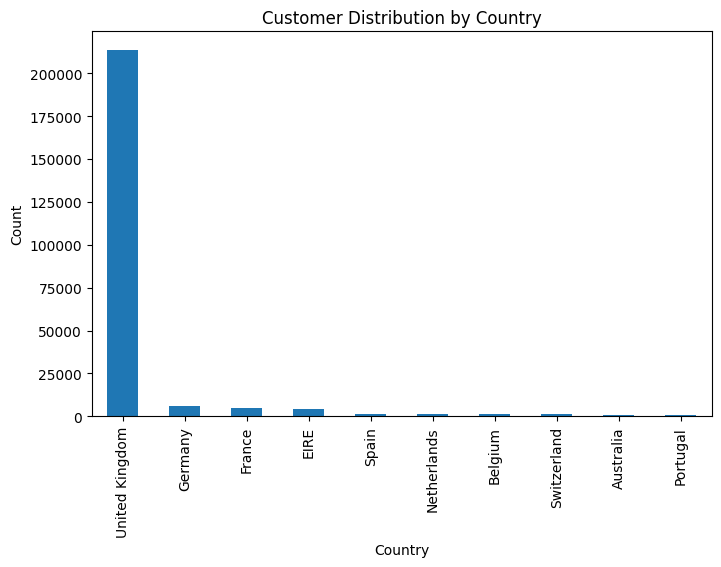

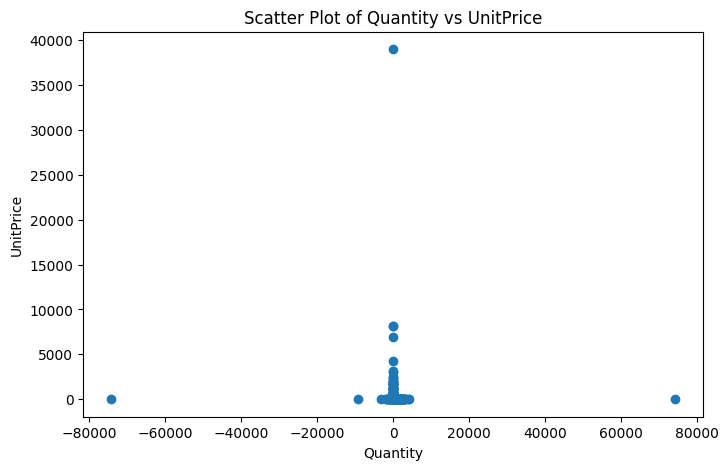


Logistic Regression

Accuracy: 0.8840926928001983

Confusion Matrix:

[[    0     0     0 ...     0   201     0]
 [    0     0     0 ...     0    58     0]
 [    0     0     0 ...     0     3     0]
 ...
 [    0     0     0 ...     0    14     0]
 [    0     0     0 ...     0 42805     0]
 [    0     0     0 ...     0    40     0]]

Decision Tree

Accuracy: 0.8847329505555785

Confusion Matrix:

[[    8     0     0 ...     0   187     0]
 [    0     0     0 ...     0    56     0]
 [    0     0     0 ...     0     3     0]
 ...
 [    0     0     0 ...     0    14     0]
 [   13     1     0 ...     0 42697     0]
 [    0     0     0 ...     0    40     0]]

KNN

Accuracy: 0.8712049237886736

Confusion Matrix:

[[   11     0     0 ...     0   166     0]
 [    0     1     0 ...     0    54     0]
 [    0     0     0 ...     0     2     0]
 ...
 [    0     0     0 ...     0    13     0]
 [   16     1     0 ...     0 41990     0]
 [    0     0     0 ...     0    40     0]]


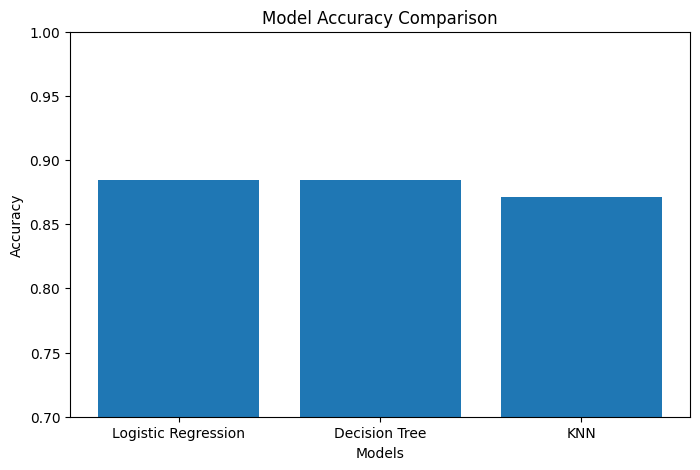


Best Model: Decision Tree
Best Accuracy: 0.8847329505555785


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix

df = pd.read_csv("customer_retail.csv")
print(df.head())

print("\nMissing Values:\n")
print(df.isnull().sum())
df = df.dropna()

df = df[['Quantity', 'UnitPrice', 'Country']]

encoder = LabelEncoder()
df['Country_encoded'] = encoder.fit_transform(df['Country'])

plt.figure(figsize=(8,5))
df['Country'].value_counts().head(10).plot(kind='bar')
plt.xlabel("Country")
plt.ylabel("Count")
plt.title("Customer Distribution by Country")
plt.show()

plt.figure(figsize=(8,5))
plt.scatter(df['Quantity'], df['UnitPrice'])
plt.xlabel('Quantity')
plt.ylabel('UnitPrice')
plt.title('Scatter Plot of Quantity vs UnitPrice')
plt.show()

x = df[['Quantity', 'UnitPrice']]
y = df['Country_encoded']

scaler = StandardScaler()
x = scaler.fit_transform(x)

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2,random_state=42)

print("\nLogistic Regression\n")

log_model = LogisticRegression(max_iter=1000)
log_model.fit(x_train, y_train)
log_pred = log_model.predict(x_test)
log_accuracy = accuracy_score(y_test, log_pred)
print("Accuracy:", log_accuracy)
log_cm = confusion_matrix(y_test, log_pred)
print("\nConfusion Matrix:\n")
print(log_cm)

print("\nDecision Tree\n")
dt_model = DecisionTreeClassifier()
dt_model.fit(x_train, y_train)
dt_pred = dt_model.predict(x_test)
dt_accuracy = accuracy_score(y_test, dt_pred)
print("Accuracy:", dt_accuracy)
dt_cm = confusion_matrix(y_test, dt_pred)
print("\nConfusion Matrix:\n")
print(dt_cm)

print("\nKNN\n")
knn_model = KNeighborsClassifier()
knn_model.fit(x_train, y_train)
knn_pred = knn_model.predict(x_test)
knn_accuracy = accuracy_score(y_test, knn_pred)
print("Accuracy:", knn_accuracy)
knn_cm = confusion_matrix(y_test, knn_pred)
print("\nConfusion Matrix:\n")
print(knn_cm)

models = [
    'Logistic Regression',
    'Decision Tree',
    'KNN'
]

accuracies = [
    log_accuracy,
    dt_accuracy,
    knn_accuracy
]

plt.figure(figsize=(8,5))
plt.bar(models, accuracies)
plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.title("Model Accuracy Comparison")
plt.ylim(0.7,1)
plt.show()

best_accuracy = max(accuracies)
best_model = models[accuracies.index(best_accuracy)]
print("\nBest Model:", best_model)
print("Best Accuracy:", best_accuracy)